# AirFly Insights: Airline Operations Analysis

## Project Goal
The goal of this project is to analyze airline flight data to identify operational trends, delay patterns, and cancellation causes using data visualization.

## Key Performance Indicators (KPIs)

1. Average arrival delay
2. Average departure delay
3. Cancellation rate
4. Busiest airlines
5. Busiest airports
6. Most common routes
7. Delay causes distribution

## Workflow

1. Data loading
2. Data exploration
3. Data cleaning
4. Feature engineering
5. Exploratory data analysis
6. Delay analysis
7. Route and airport analysis
8. Final visualization dashboard

In [2]:
#Import Required Libraries
import pandas as pd
import numpy as np

#import matplotlib.pyplot as plt 
#import seaborn as sns 
#import plotly.express as px



In [3]:
#Load Dataset
df = pd.read_csv(r"C:\Users\Pallav\Downloads\airflydata\flights_sample_3m.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Initial Data Exploration
df.shape #Dataset shape

(3000000, 32)

In [5]:
df.columns #Check column names

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [6]:
df.info() #Dataset Information(Schema)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [7]:
df.isnull().sum() #Checking missing values

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [8]:
df.describe() #Statistical Summary

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [9]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE']) #Convert Date Column
df['DAY_NAME'] = df['FL_DATE'].dt.day_name()

In [10]:
#Extract Time Features

df['MONTH'] = df['FL_DATE'].dt.month
df['DAY'] = df['FL_DATE'].dt.day
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek

Week2- Preprocessing and Feature Engineering

In [11]:
df['DEP_DELAY'] = df['DEP_DELAY'].fillna(0) #Handle Missing Delays
df['ARR_DELAY'] = df['ARR_DELAY'].fillna(0)

In [12]:
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna("None") #Handle Cancellation Reason

In [13]:
df['ROUTE'] = df['ORIGIN'] + "-" + df['DEST'] #Create Route Feature

In [14]:
df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100 #Create Hour Feature

In [15]:
df.to_csv("cleaned_airflights.csv", index=False) #Save clean Dataset

Milestone 2: Visual Exploration and Delay Trends 

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

WEEK 3 — Univariate and Bivariate Visual Analysis

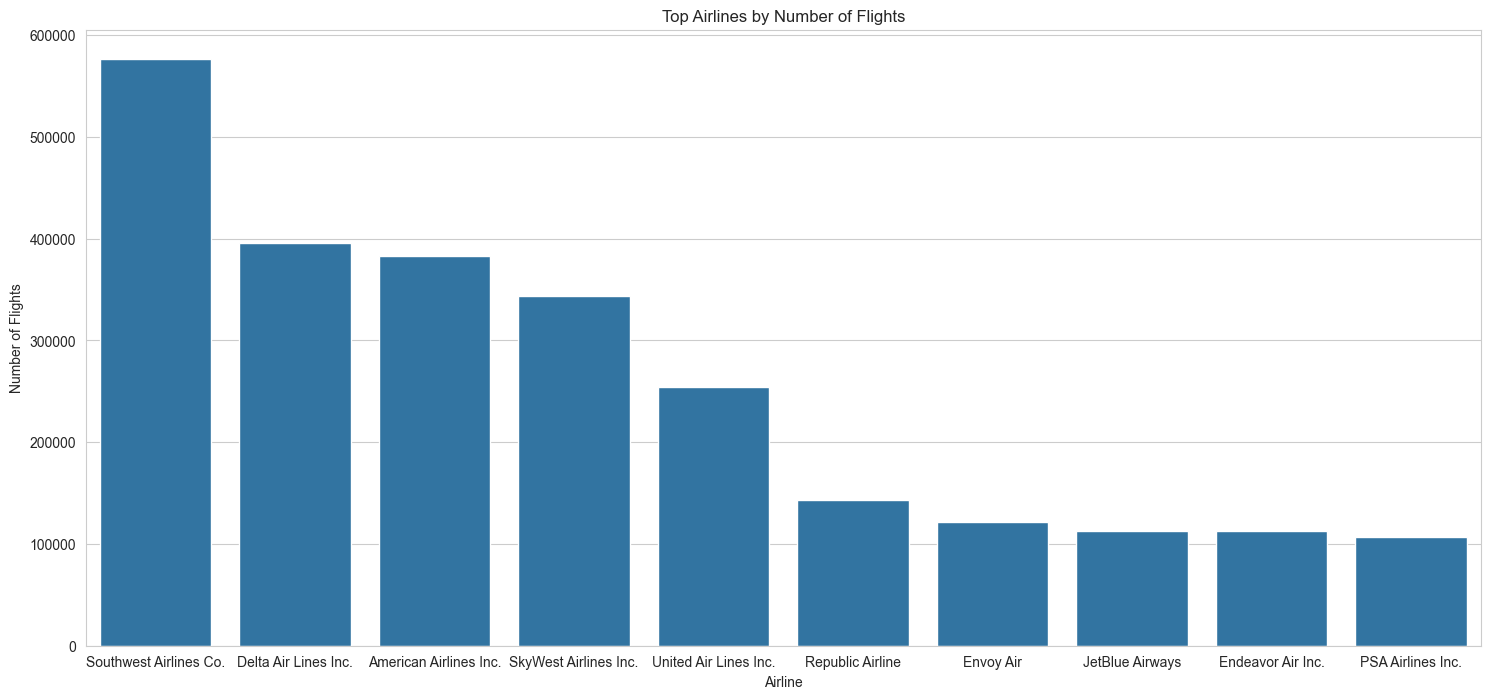

In [17]:
top_airlines = df['AIRLINE'].value_counts().head(10) #Top Airlines by Number of Flights (Bar Chart)

plt.figure(figsize=(18,8))
sns.barplot(x=top_airlines.index, y=top_airlines.values)

plt.title("Top Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.show()

Airlines like SWA and DL operate the highest number of flights, indicating their dominant market presence.

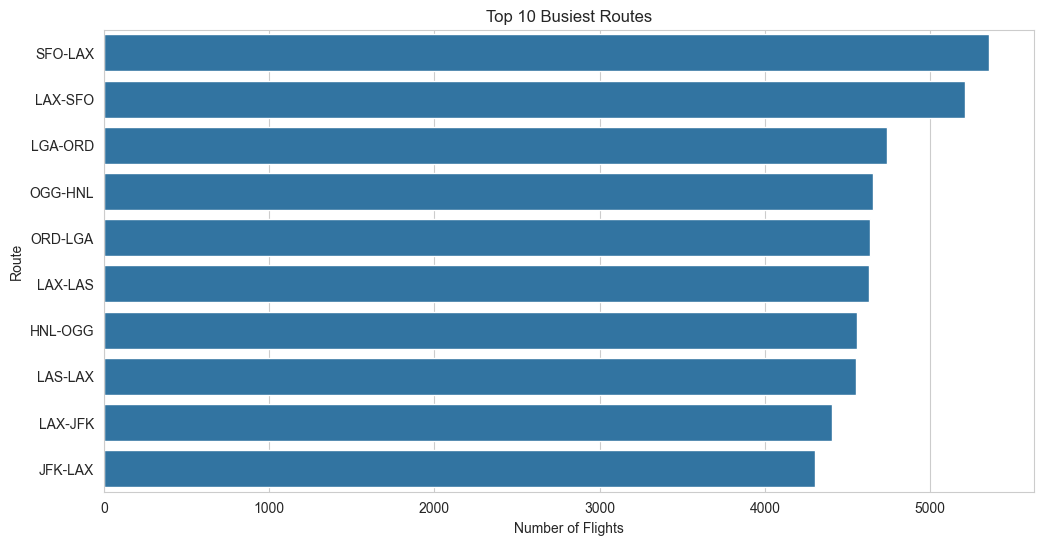

In [18]:
#Top 10 Routes (Bar Chart)
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

Certain short-haul routes appear most frequently, suggesting heavy passenger demand between major hubs.

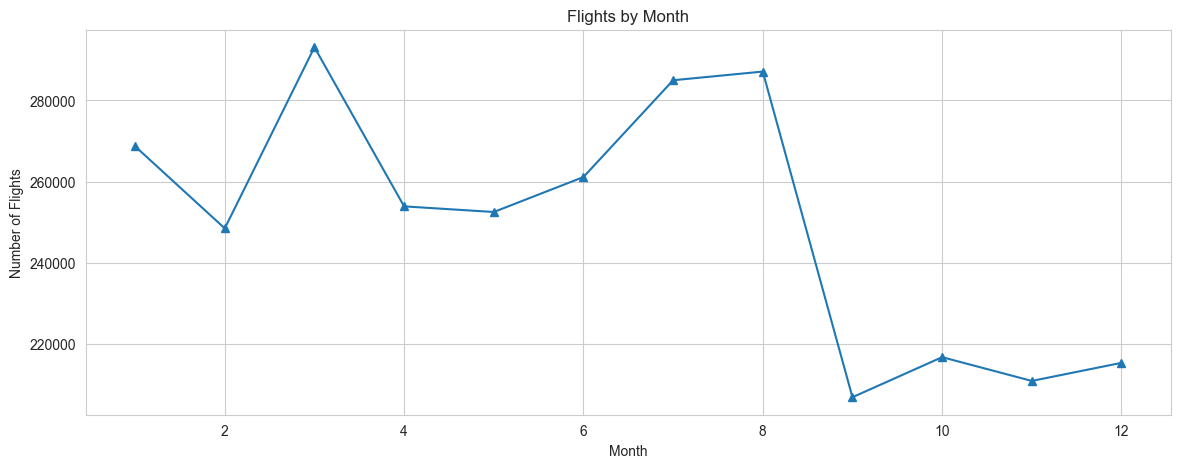

In [19]:
#Busiest Months (Line Plot)
monthly_flights = df.groupby('MONTH').size()

plt.figure(figsize=(14,5))
monthly_flights.plot(marker='^')

plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.show()

Summer months show increased flight activity due to vacation travel.

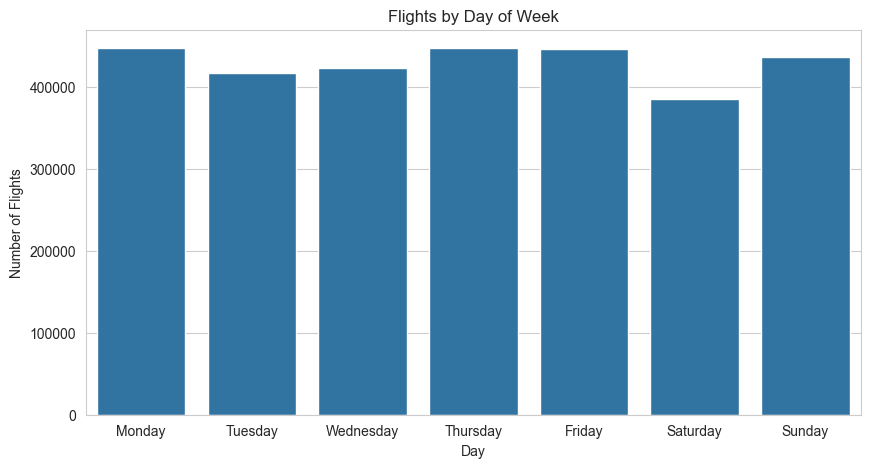

In [20]:
#Flight Distribution by Day of Week (Bar Chart)
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='DAY_NAME',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")

plt.show()

Weekdays generally have more flights than weekends due to business travel demand.

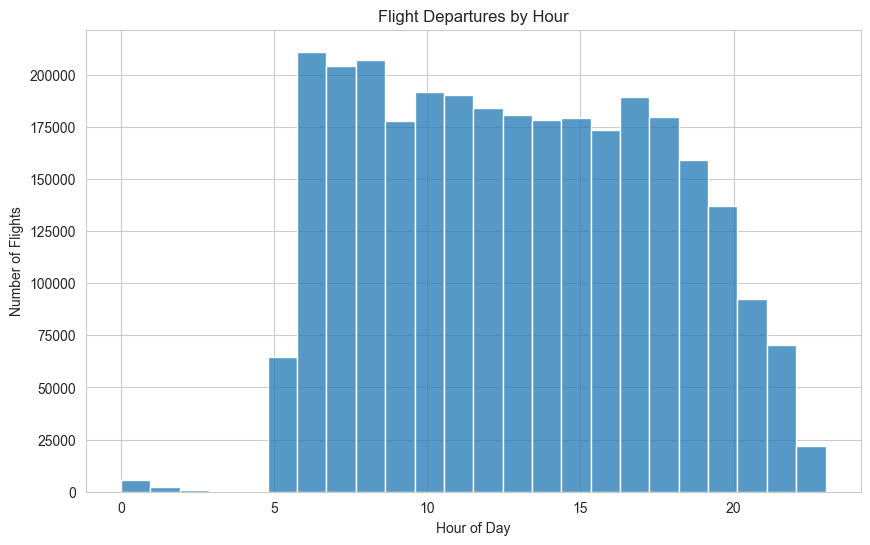

In [21]:
#Flights by Departure Hour (Histogram)
plt.figure(figsize=(10,6))

sns.histplot(df['DEP_HOUR'], bins=24)

plt.title("Flight Departures by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")

plt.show()

Flights peak during early morning and evening hours, corresponding to commuter and business travel patterns.

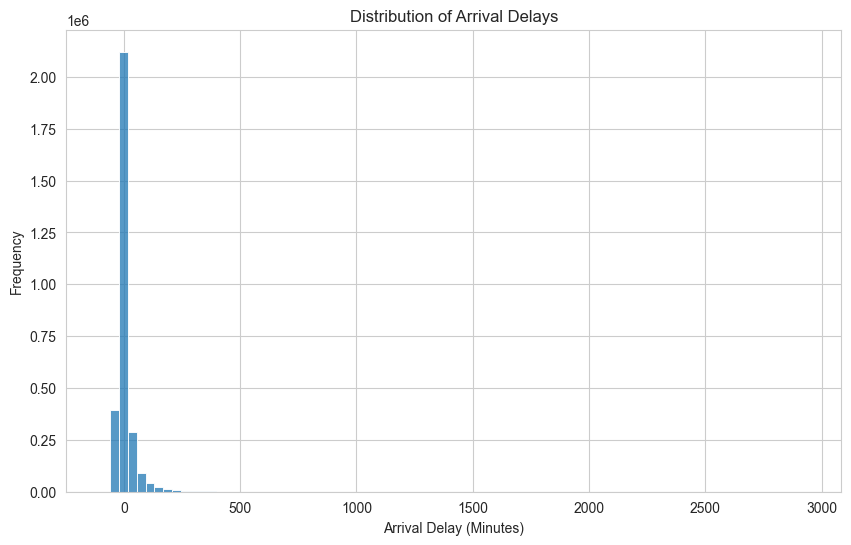

In [22]:
#Delay Distribution (Histogram)
plt.figure(figsize=(10,6))

sns.histplot(df['ARR_DELAY'], bins=80)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Frequency")

plt.show()

Most flights experience small delays, while a few flights show extreme delays (long right tail).

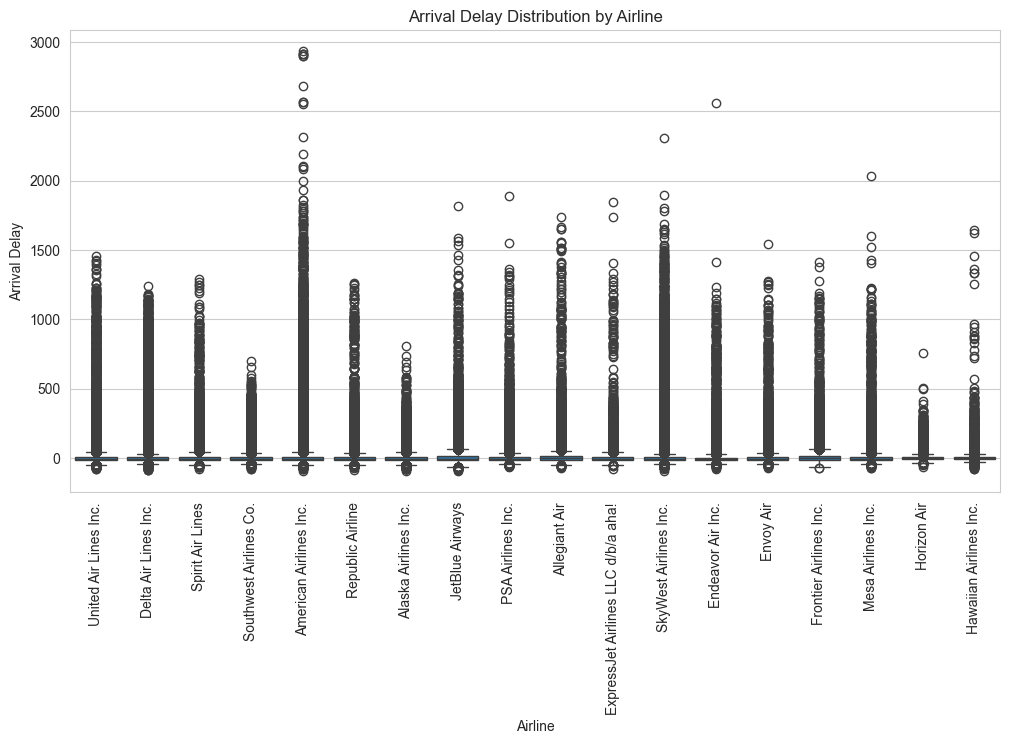

In [23]:
#Arrival Delay by Airline (Boxplot)
plt.figure(figsize=(12,6))

sns.boxplot(x='AIRLINE', y='ARR_DELAY', data=df)

plt.title("Arrival Delay Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Arrival Delay")

plt.xticks(rotation=90)

plt.show()

What Boxplot Shows- median delay, variability, extreme delays.
Some airlines exhibit larger variability and higher median delays compared to others.

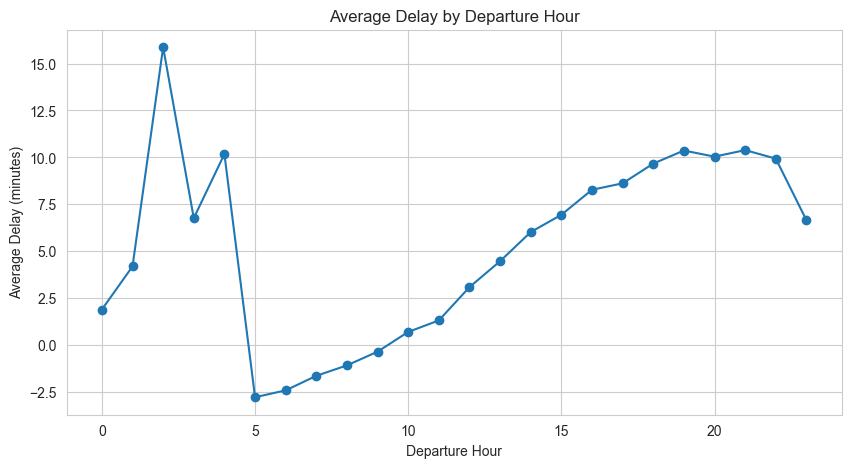

In [24]:
#Average Delay by Departure Hour (Line Plot)
delay_by_hour = df.groupby('DEP_HOUR')['ARR_DELAY'].mean()

plt.figure(figsize=(10,5))
delay_by_hour.plot(marker='o')

plt.title("Average Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay (minutes)")

plt.show()

Flights departing later in the day tend to experience higher delays due to cascading schedule disruptions.

WEEK 4 — Delay Analysis (Airline and Weather)

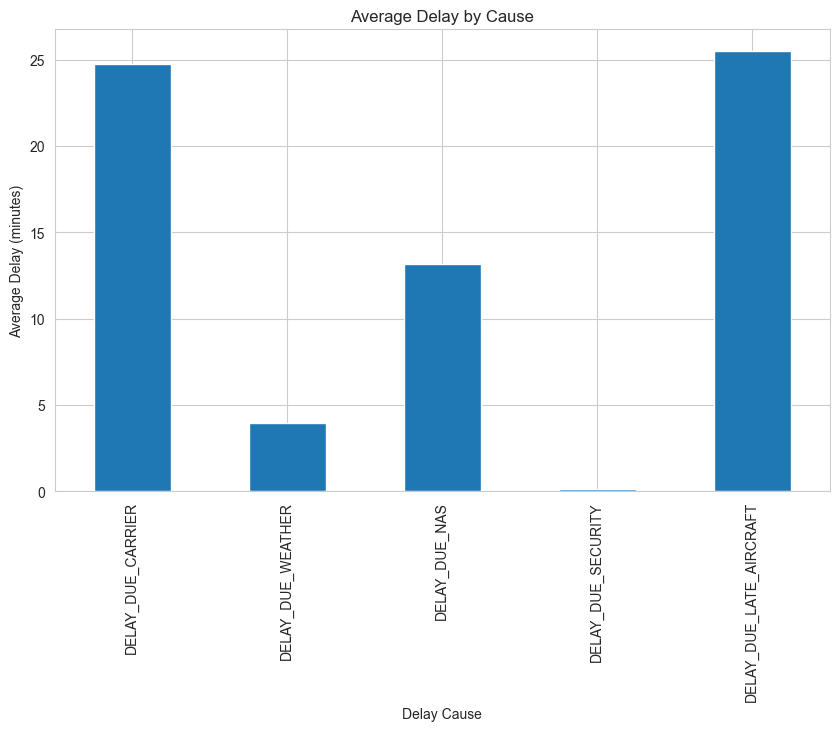

In [25]:
#Average Delay by Cause
delay_causes = df[[
'DELAY_DUE_CARRIER',
'DELAY_DUE_WEATHER',
'DELAY_DUE_NAS',
'DELAY_DUE_SECURITY',
'DELAY_DUE_LATE_AIRCRAFT'
]].mean()

delay_causes.plot(kind='bar', figsize=(10,6))

plt.title("Average Delay by Cause")
plt.ylabel("Average Delay (minutes)")
plt.xlabel("Delay Cause")

plt.show()

Carrier and late aircraft delays contribute the largest portion of total delays.

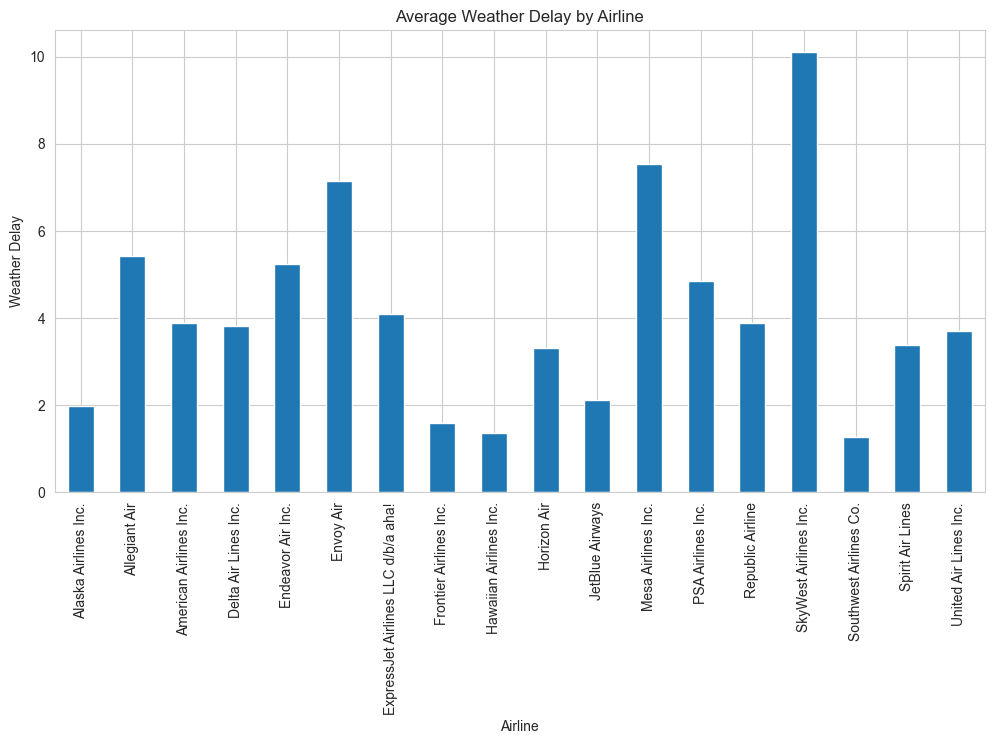

In [26]:
#Weather Delay by Airline
weather_delay_airline = df.groupby('AIRLINE')['DELAY_DUE_WEATHER'].mean()

plt.figure(figsize=(12,6))
weather_delay_airline.plot(kind='bar')

plt.title("Average Weather Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Weather Delay")

plt.show()

Airlines operating in weather-prone regions show higher average weather delays.

## Key Findings

1. Certain airlines dominate flight operations.
2. Short-haul routes between major hubs are the busiest.
3. Flight activity peaks during summer months.
4. Departure activity is highest in early morning and evening hours.
5. Most delays are small but some extreme delays exist.
6. Late aircraft and carrier delays contribute most to total delays.
7. Average delays increase later in the day.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Milestone 3: Route, Cancellation, and Seasonal Insights

WEEK 5 — Route and Airport-Level Analysis

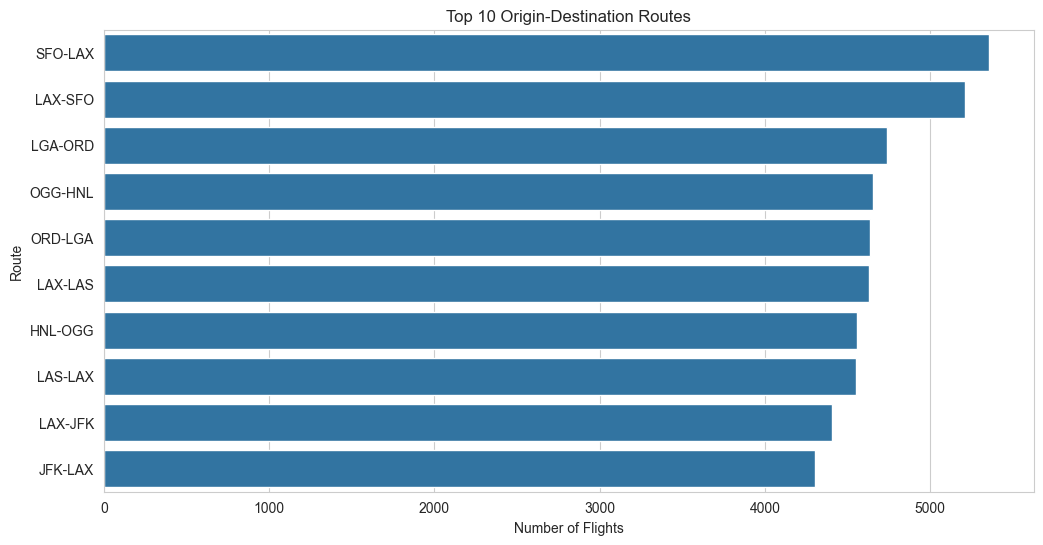

In [27]:
#Top 10 Origin–Destination Pairs

top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Origin-Destination Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

Certain high-demand short-haul routes dominate flight operations, especially between major hub airports.

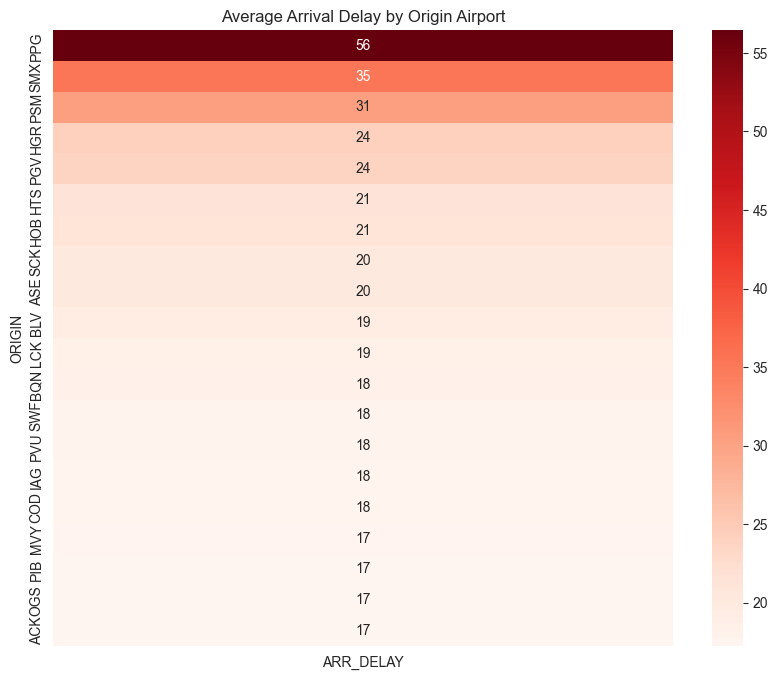

In [28]:
#Delay Heatmap by Airport
airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))

sns.heatmap(
    airport_delay.to_frame(),
    cmap="Reds",
    annot=True
)

plt.title("Average Arrival Delay by Origin Airport")
plt.show()

Some airports consistently experience higher delays, likely due to congestion or weather conditions.

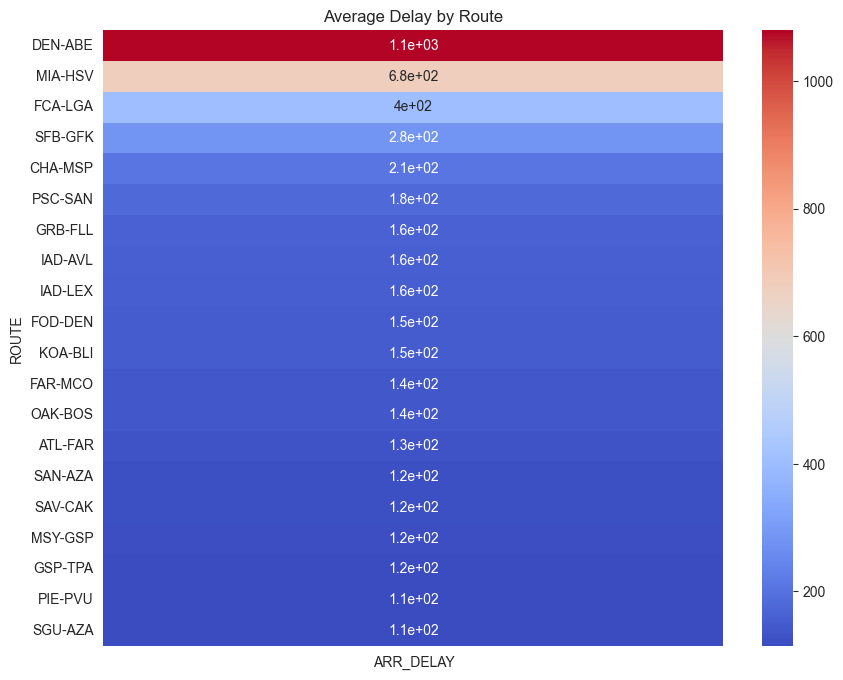

In [29]:
#Delay Heatmap by Route

route_delay = df.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))

sns.heatmap(
    route_delay.to_frame(),
    cmap="coolwarm",
    annot=True
)

plt.title("Average Delay by Route")
plt.show()

Certain routes experience higher delays, suggesting operational or weather-related challenges between specific airport pairs.

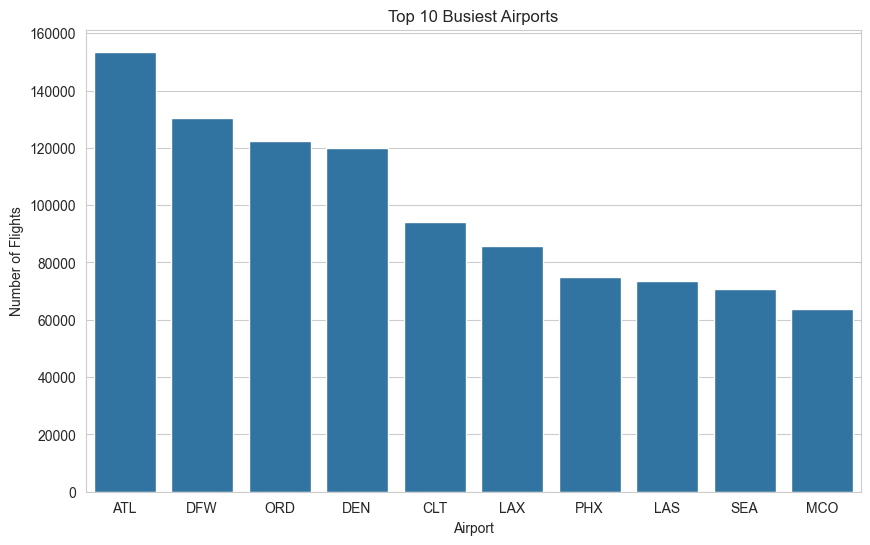

In [30]:
#Busiest Airports

busiest_airports = df['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=busiest_airports.index, y=busiest_airports.values)

plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")

plt.show()

Major hub airports handle significantly higher traffic compared to regional airports.

In [ ]:
#Map of Busiest Airports

import folium
from IPython.display import display
map_airports = folium.Map(location=[39.5, -98.35], zoom_start=4)

folium.Marker(
    location=[33.64, -84.42],
    popup="ATL Airport"
).add_to(map_airports)

map_airports

In [32]:
map_airports.save("busiest_airports_map.html")

WEEK 6 — Seasonal and Cancellation Analysis

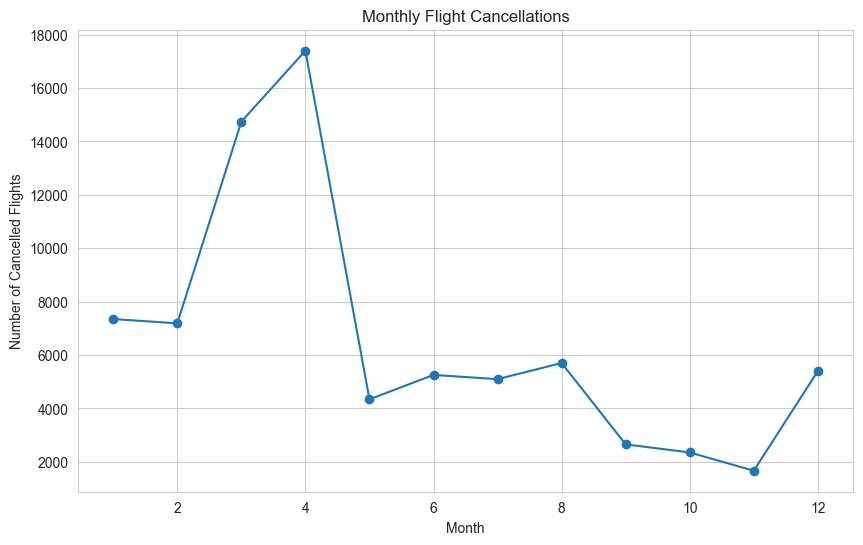

In [33]:
#Monthly Cancellation Trends

cancelled = df[df['CANCELLED'] == 1]

monthly_cancel = cancelled.groupby('MONTH').size()

plt.figure(figsize=(10,6))

monthly_cancel.plot(marker='o')

plt.title("Monthly Flight Cancellations")
plt.xlabel("Month")
plt.ylabel("Number of Cancelled Flights")

plt.show()

Cancellations often peak during winter months due to adverse weather conditions.

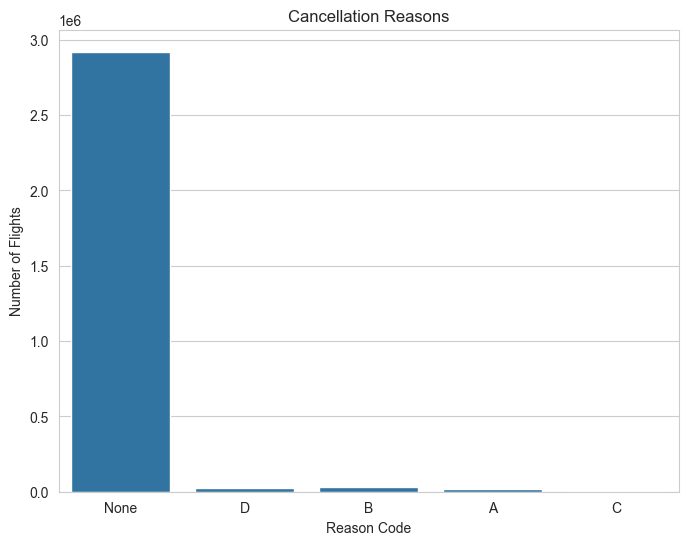

In [34]:
#Cancellation Types
plt.figure(figsize=(8,6))

sns.countplot(data=df, x='CANCELLATION_CODE')

plt.title("Cancellation Reasons")
plt.xlabel("Reason Code")
plt.ylabel("Number of Flights")

plt.show()

Most cancellations are due to airline operational issues and weather disruptions.

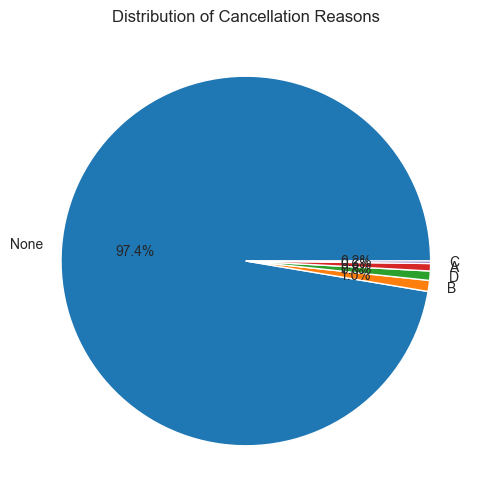

In [35]:
#Cancellation Reasons Breakdown

cancel_reason = df['CANCELLATION_CODE'].value_counts()

cancel_reason.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title("Distribution of Cancellation Reasons")
plt.ylabel("")

plt.show()

Weather-related cancellations form a significant proportion of all cancellations.

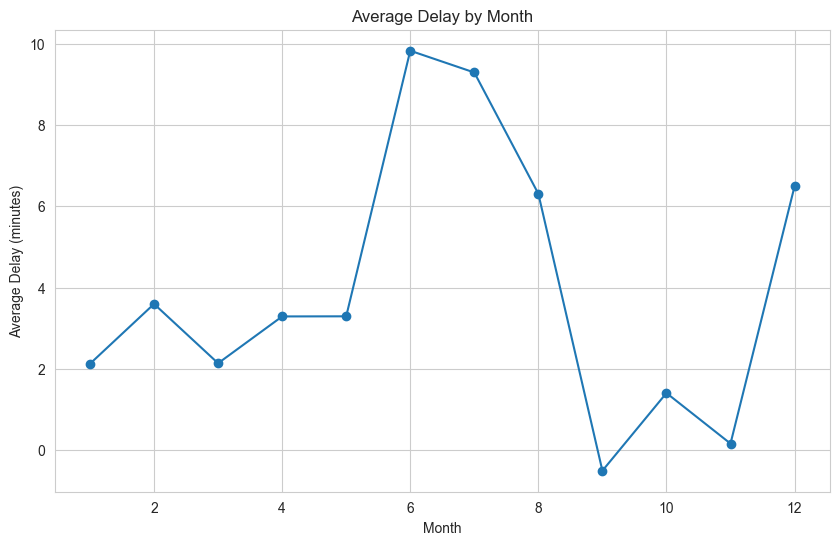

In [36]:
#Seasonal Delay Trends

seasonal_delay = df.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(10,6))

seasonal_delay.plot(marker='o')

plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.show()

Delays tend to increase during peak travel seasons and winter months.

In [37]:
#Winter Impact Analysis
winter = df[df['MONTH'].isin([12,1,2])]

winter_delay = winter['ARR_DELAY'].mean()

print("Average Winter Delay:", winter_delay)

Average Winter Delay: 3.90824993038379


Flights during winter months experience higher average delays due to weather disruptions such as snowstorms.

## Milestone 3 Key Findings

1. Several high-demand routes dominate airline traffic.
2. Major hub airports handle the majority of flights.
3. Some airports consistently experience higher delays.
4. Winter months show increased cancellations due to weather.
5. Weather and carrier issues are the most common cancellation causes.